# PubMed literature check.
(compound <-> AD evidence)

In [1]:
import pandas as pd
import requests
import time


EUTILS = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils"

# Load Ro5 passers
cands = pd.read_csv("jupyter_output/candidates_with_drugcentral.csv")
#cands = cands.drop_duplicates(subset=["compound"]).copy()
cands = cands.drop_duplicates(subset=["compound", "gene"]).copy()
print("Compounds to check:", len(cands))

Compounds to check: 75


In [2]:
# optional for future use (NCBI etiquette, higher rate limit)
EMAIL = "ochiramg@gmail.com"

def pubmed_count(query):
    """Return number of PubMed hits for a query."""
    url = f"{EUTILS}/esearch.fcgi"
    params = {
        "db": "pubmed",
        "term": query,
        "retmode": "json",
        "retmax": 5,  # also grab a few PMIDs
        "email": EMAIL,
    }
    try:
        r = requests.get(url, params=params, timeout=15)
        if r.status_code != 200:
            return None, []
        data = r.json()["esearchresult"]
        count = int(data.get("count", 0))
        pmids = data.get("idlist", [])
        return count, pmids
    except Exception:
        return None, []

In [8]:
# build queries: compound name AND Alzheimer's terms
AD_TERMS = '("Alzheimer" OR "Alzheimer\'s disease" OR "neurodegeneration")'

def check_compound(name):
    if pd.isna(name) or str(name).strip() == "":
        return {"ad_evidence": "Unclear", "ad_hits": 0, "note": "no compound name", "pmids": ""}

    # query 1: compound + AD
    q_ad = f'"{name}" AND {AD_TERMS}'
    ad_count, ad_pmids = pubmed_count(q_ad)
    time.sleep(0.34)

    # query 2: compound alone (context. is it studied at all?)
    total_count, _ = pubmed_count(f'"{name}"')
    time.sleep(0.34)

    if ad_count is None:
        return {"ad_evidence": "Unclear", "ad_hits": None, "note": "query error", "pmids": ""}

    # classify
    if ad_count >= 3:
        evidence = "Yes"
        note = f"{ad_count} AD-related papers"
    elif ad_count >= 1:
        evidence = "Unclear"
        note = f"only {ad_count} AD paper(s). weak/indirect"
    else:
        evidence = "No"
        if total_count and total_count > 0:
            note = f"studied ({total_count} papers) but none AD-related"
        else:
            note = "no PubMed presence"

    return {
        "ad_evidence": evidence,
        "ad_hits": ad_count,
        "total_hits": total_count,
        "note": note,
        "pmids": ",".join(ad_pmids),
    }

In [9]:
# run PubMed only on unique compound names
unique_names = cands["compound"].dropna().unique()
results = []
for i, name in enumerate(unique_names, start=1):
    print(f"{i}/{len(unique_names)} {name}")
    info = check_compound(name)
    info["compound"] = name
    results.append(info)

lit_df = pd.DataFrame(results)
lit_df.head(20)
# Merge back onto ALL gene rows
final = cands.merge(lit_df, on="compound", how="left")

1/69 3-{2-[4-(6-Fluoro-benzo[d]isoxazol-3-yl)-piperidin-1-yl]-ethyl}-2-methyl-6,7,8,9-tetrahydro-pyrido[1,2-a]pyrimidin-4-one (Resperidone)
2/69 5-(4-Chloro-phenyl)-6-ethyl-pyrimidine-2,4-diamine
3/69 Chlorambucil
4/69 Cyclobenzaprine
5/69 Doxylamine
6/69 Estriol
7/69 Estrone
8/69 Finasteride
9/69 Haloperidol
10/69 Kinetin
11/69 Levofloxacin
12/69 Lisuride
13/69 Mianserin
14/69 Naltrexone
15/69 Naproxen
16/69 Primaquine
17/69 acebutolol
18/69 amitriptyline
19/69 benactyzine
20/69 diethylstilbestrol
21/69 pivampicillin
22/69 prednisolone
23/69 prednisone
24/69 spironolactone
25/69 tretinoin
26/69 3-(dibenzo[b,e]oxepin-11(6H)-ylidene)-N,N-dimethylpropan-1-amine
27/69 4-Amino-1-(5-hydroxymethyl-tetrahydro-furan-2-yl)-1H-pyrimidin-2-one
28/69 4-Amino-N-(2-diethylamino-ethyl)-benzamide
29/69 Acetohexamide
30/69 Benzocaine
31/69 Cinchocaine
32/69 Genistein
33/69 Glipizide
34/69 Melatonin
35/69 Melperone
36/69 Nortriptyline
37/69 Pioglitazone
38/69 Sulfadimethoxine
39/69 Trazodone
40/69 cloza

In [10]:
# merge back and save
final.to_csv("jupyter_output/candidates_with_literature.csv", index=False)
print("Saved: candidates_with_literature.csv")
print(final["ad_evidence"].value_counts())

Saved: candidates_with_literature.csv
ad_evidence
Yes        43
No         19
Unclear    13
Name: count, dtype: int64


# Cool figures


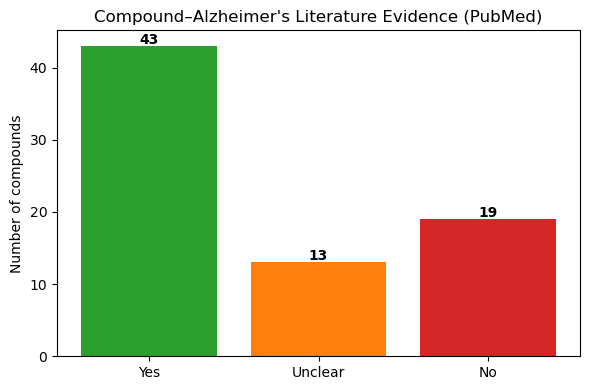

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

final = pd.read_csv("jupyter_output/candidates_with_literature.csv")

# Count evidence categories
counts = final["ad_evidence"].value_counts().reindex(["Yes", "Unclear", "No"]).fillna(0)

fig, ax = plt.subplots(figsize=(6, 4))
colors = {"Yes": "#2ca02c", "Unclear": "#ff7f0e", "No": "#d62728"}
ax.bar(counts.index, counts.values, color=[colors[c] for c in counts.index])

ax.set_ylabel("Number of compounds")
ax.set_title("Compound–Alzheimer's Literature Evidence (PubMed)")
for i, v in enumerate(counts.values):
    ax.text(i, v + 0.3, int(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

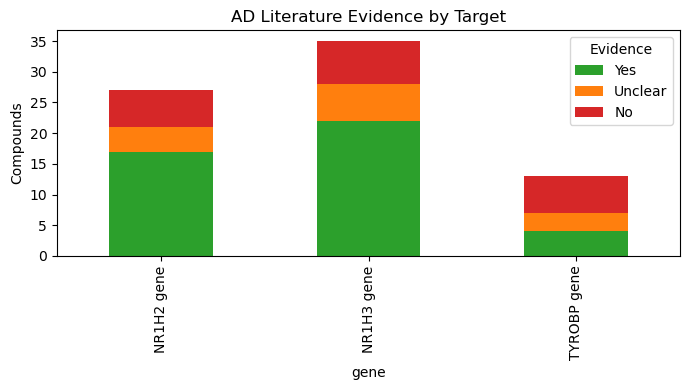

In [3]:
pivot = final.groupby(["gene", "ad_evidence"]).size().unstack(fill_value=0)
pivot = pivot.reindex(columns=["Yes", "Unclear", "No"], fill_value=0)

pivot.plot(kind="bar", stacked=True, figsize=(7, 4),
           color=["#2ca02c", "#ff7f0e", "#d62728"])
plt.ylabel("Compounds")
plt.title("AD Literature Evidence by Target")
plt.legend(title="Evidence")
plt.tight_layout()
plt.show()

# Debugging compound that could get wrong PubChem API call
(e.g. 43k AD hits while total hits 0 compound)

In [3]:
lit = pd.read_csv("jupyter_output/candidates_with_literature.csv")

suspicious = lit[
    (lit["ad_hits"] > lit["total_hits"]) |
    (lit["ad_hits"] > 1000)
]
print(suspicious[["compound", "ad_hits", "total_hits"]])

                                    compound  ad_hits  total_hits
35                                 Melatonin     1153       37392
51  7,8-dihydroxy-6-methoxy-2H-chromen-2-one    43457           0


In [5]:
# rerun those compounds with a small delay + retry
AD_TERMS = '("Alzheimer" OR "Alzheimer\'s disease" OR "neurodegeneration")'

def recheck(name):
    total, _ = pubmed_count(f'"{name}"')
    time.sleep(0.5)
    ad, pmids = pubmed_count(f'"{name}" AND {AD_TERMS}')
    time.sleep(0.5)
    return total, ad, pmids

for idx, row in suspicious.iterrows():
    total, ad, pmids = recheck(row["compound"])
    print(row["compound"], "-> total:", total, "ad:", ad)
    lit.loc[idx, "total_hits"] = total
    lit.loc[idx, "ad_hits"] = ad
    lit.loc[idx, "pmids"] = ",".join(pmids)

lit.to_csv("jupyter_output/candidates_with_literature.csv", index=False)

Melatonin -> total: 37392 ad: 1153
7,8-dihydroxy-6-methoxy-2H-chromen-2-one -> total: 0 ad: 43467


In [6]:
#see the raw query PubMed is running
name = "7,8-dihydroxy-6-methoxy-2H-chromen-2-one"
r = requests.get(f"{EUTILS}/esearch.fcgi", params={
    "db": "pubmed", "term": f'"{name}"', "retmode": "json", "email": EMAIL
})
print(r.json()["esearchresult"].get("querytranslation"))

"7,8-dihydroxy-6-methoxy-2H-chromen-2-one"


In [9]:
#solved
r = requests.get(f"{EUTILS}/esearch.fcgi", params={
    "db": "pubmed",
    "term": f'"{name}" AND {AD_TERMS}',
    "retmode": "json", "email": EMAIL
})
print(r.json()["esearchresult"].get("querytranslation"))

"7"[All Fields] AND ("Alzheimer"[All Fields] OR "Alzheimer's disease"[All Fields] OR "neurodegeneration"[All Fields])


In [8]:
lit = pd.read_csv("jupyter_output/candidates_with_literature.csv")

#hard coding it 
#if the compound has no PubMed presence at all, its AD hits are spurious
mask = lit["total_hits"] == 0
lit.loc[mask, "ad_hits"] = 0
lit.loc[mask, "ad_evidence"] = "No"
lit.loc[mask, "note"] = "no PubMed presence (name not found)"
lit.loc[mask, "pmids"] = ""

lit.to_csv("jupyter_output/candidates_with_literature.csv", index=False)
print(lit["ad_evidence"].value_counts())

ad_evidence
Yes        42
No         20
Unclear    13
Name: count, dtype: int64
